# Cumulative Numerical Integration

In certain cases, the quantity of interest is not a single value obtained from an integral, but the entire accumulated function itself. In such situations, cumulative numerical integration is required, where the integral is evaluated progressively over the independent variable. In this notebook, cumulative numerical integration is applied to the computation of electric charge, which is obtained by integrating the electric current with respect to time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid, cumulative_simpson

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

If the electric current is given by

$$
I(t)=I_0 t^n e^{-\frac{t}{\tau}},
$$

then the accumulated electric charge is

$$
q(t)=\int_{0}^{t}I(\xi)\,d\xi
$$

where $I_0$ is the current amplitude, $\tau$ is the time constant, and $n$ controls the shape of the waveform.

In [3]:
I0, tau, n = 4, 0.7, 3
t = np.linspace(0, 8, 1000)
i = I0 * (t**n) * np.exp(-t/tau)

The following figure shows the waveform of the current function $I(t)$. The current initially increases due to the factor $t^n$ and subsequently decreases exponentially because of the term $\exp(−t/\tau)$.

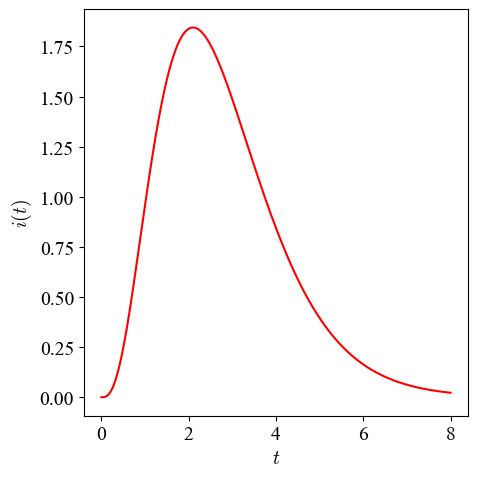

In [4]:
plt.figure(figsize=(5, 5))
plt.plot(t, i, color="r")
plt.xlabel(r"$t$")
plt.ylabel(r"$i(t)$")
plt.tight_layout()
plt.show()

The cumulative integral is approximated using the trapezoidal and Simpson's rule. In this notebook, these methods are implemented using `scipy.integrate.cumulative_trapezoid` and `scipy.integrate.cumulative_simpson`.

In [5]:
q_trap = cumulative_trapezoid(i, t, initial=0)
q_simp = cumulative_simpson(i, x=t, initial=0)

The following figure presents the cumulative charge $q(t)$ obtained from both numerical integration methods. The curves represent the progressive accumulation of electric charge over time.

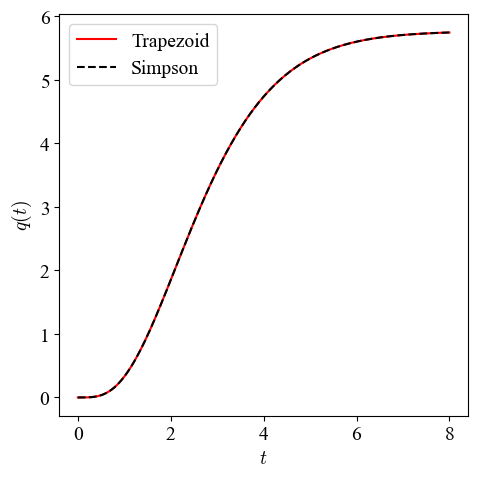

In [6]:
plt.figure(figsize=(5, 5))
plt.plot(t, q_trap, color="r", label="Trapezoid")
plt.plot(t, q_simp, "--", color="k", label="Simpson")
plt.xlabel(r"$t$")
plt.ylabel(r"$q(t)$")
plt.legend()
plt.tight_layout()
plt.show()

## Key Insights

* Cumulative numerical integration returns an accumulation function rather than a single scalar value.
* Integrating the current function $I(t)$ over time produces the cumulative electric charge $q(t)$.
* The Trapezoidal and Simpson cumulative methods generate closely matching charge profiles, indicating good numerical consistency.